---
title: "Volatility Forecasts (Part 4 — RMSE Benchmarks and QLIKE Training)"
date: 2026-03-03
description: "We keep RMSE for benchmark comparability, then refit STES and XGBSTES under QLIKE to see how the training loss changes out-of-sample ranking and calibration."
categories: [Quantitative Finance, Volatility Modeling, Time Series]
content-type: "series"
series-id: "volatility-forecasting"
series-title: "Volatility Forecasts"
series-part: 4
project-ids: [volatility-forecasting]
format:
  html:
    toc: true
    code-fold: true
execute:
  echo: true
  warning: false
  message: false
  freeze: false
---

## Introduction

In [Part 3](../volatility-forecasts-3/) we showed that replacing the fixed smoothing coefficient in exponential smoothing with a learned gate improves one-step-ahead volatility forecasts. The best model in that post was **XGBSTES**, where the gate is learned by a gradient-boosted linear model rather than a single logistic regression. Every result so far has been trained and scored under RMSE, following the paper from [Part 1](../volatility-forecasts-1/) ([Liu, Taylor & Choo, 2020](https://doi.org/10.1002/for.2648)).

Before adding new covariates, we want to settle a more basic modeling choice: **what loss function should train the model?** RMSE is a common choice for forecasting task in general, but for variance forecasts the more natural objective is often **QLIKE**.

The case for QLIKE rests on two properties established in the forecast-evaluation literature. First, [Patton (2011)](https://doi.org/10.1016/j.jeconom.2010.07.008) showed that QLIKE belongs to the class of loss functions that are *robust* to noise in the volatility proxy — it ranks forecasts consistently even when realized variance is measured with error. Second, [Hansen and Lunde (2005)](https://doi.org/10.1198/073500105000000063) demonstrated that QLIKE provides a *consistent* ranking function for conditional-variance models, meaning the best forecast under the population criterion wins in large samples regardless of the proxy used.

Practically, the difference matters because RMSE is level-sensitive: a few large volatility spikes dominate the score. QLIKE evaluates forecasts proportionally, so it is more informative about whether the model is systematically too high or too low as a *variance* forecast, not just whether it tracks large episodes in absolute magnitude. A model can look strong under RMSE by following big moves, yet score poorly under QLIKE because it is miscalibrated on a proportional basis. Rather than choosing one metric by convention, this post compares both directly.

The questions are:

1. **Do the MSE-trained models still compare well on the fixed split from the earlier posts?**
2. **What changes when we retrain each model family under QLIKE, keeping the same features and split?**
3. **Do MSE and QLIKE lead to different out-of-sample rankings or calibration judgments?**

We keep the same SPY sample spanning January 2000 through December 2023. As in Part 3, we use the first 200 observations as warm-up, use observations 201 through 4,000 for estimation, and reserve the remainder for out-of-sample evaluation. The target remains next-day squared return. The scope of this post is limited to the QLIKE loss-function question. We derive the QLIKE gradient for STES, show how it enters the XGBSTES custom objective, and compare all seven model variants empirically. Regularization and feature expansion are deferred to [Part 5](../volatility-forecasts-5/).

In [88]:
#| echo: false
#| output: false


import sys
import os
import logging
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv

# --- PATH SETUP ---
WORKSPACE_ROOT = Path("/Users/steveyang/Projects/Github")
BLOG_PATH = WORKSPACE_ROOT / "steveya.github.io"
VF_PATH = WORKSPACE_ROOT / "volatility-forecast"
AF_PATH = WORKSPACE_ROOT / "alphaforge"

for p in (BLOG_PATH, VF_PATH, AF_PATH):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

load_dotenv(VF_PATH / ".env")
logging.basicConfig(level=logging.ERROR)

# --- LIBRARY IMPORTS ---
from alphaforge.data.cache import FileCacheBackend
from alphaforge.data.query import Query
from volatility_forecast.pipeline import build_default_ctx
from volatility_forecast.sources import TiingoEODSource
from volatility_forecast.evaluation.metrics import rmse, mae, qlike
from volatility_forecast.evaluation.dm_test import diebold_mariano
from volatility_forecast.evaluation.mz import mincer_zarnowitz

from blog_styles import (
    style_results_table, inject_blog_table_css,
    apply_blog_plot_style, BLOG_PALETTE,
)

# Replication cache lock (same cache path convention as script)
SCRIPT_CACHE_DIR = VF_PATH / ".af_cache"
SCRIPT_CACHE_MODE = "use"

# --- STYLES ---
inject_blog_table_css()
apply_blog_plot_style()

# --- DATA CONTEXT ---
cache = FileCacheBackend(SCRIPT_CACHE_DIR)
ctx = build_default_ctx(
    tiingo_api_key=os.environ.get("TIINGO_API") or os.environ.get("TIINGO_API_KEY"),
    tiingo_cache_backends=[cache],
    tiingo_cache_mode=SCRIPT_CACHE_MODE,
)
print(f"Tiingo cache dir: {SCRIPT_CACHE_DIR}")
print(f"Tiingo cache mode: {SCRIPT_CACHE_MODE}")

Tiingo cache dir: /Users/steveyang/Projects/Github/volatility-forecast/.af_cache
Tiingo cache mode: use


In [89]:
#| echo: false
#| output: false

# Shared sample window used throughout the notebook
SAMPLE_TICKER = "SPY"
SAMPLE_START = pd.Timestamp("2000-01-01", tz="UTC")
SAMPLE_END = pd.Timestamp("2023-12-31", tz="UTC")

# TiingoEODSource cache key convention: "{ticker}|adj={use_adjusted}"
sample_cache_key = f"{SAMPLE_TICKER}|adj=True"
sample_cached = cache.get(sample_cache_key)

if sample_cached is None or sample_cached.empty:
    raise RuntimeError(
        f"Cache-only mode: no cached data found for key={sample_cache_key} in {SCRIPT_CACHE_DIR}. "
        "Populate cache via script first; notebook will not reload from Tiingo."
    )

sample_cached = sample_cached.copy()
sample_cached["date"] = pd.to_datetime(sample_cached["date"], utc=True).dt.normalize()
cache_min = sample_cached["date"].min()
cache_max = sample_cached["date"].max()

# Compare against business-day endpoints (requested endpoints may be weekends/holidays)
requested_bdays = pd.bdate_range(SAMPLE_START.tz_convert(None), SAMPLE_END.tz_convert(None))
need_start = pd.Timestamp(requested_bdays.min(), tz="UTC")
need_end = pd.Timestamp(requested_bdays.max(), tz="UTC")

if not (cache_min <= need_start and cache_max >= need_end):
    raise RuntimeError(
        "Cache-only mode: cached coverage is insufficient for sample window. "
        f"Need business-day coverage [{need_start.date()}..{need_end.date()}], "
        f"have [{cache_min.date()}..{cache_max.date()}]. "
        "Populate cache via script first; notebook will not reload from Tiingo."
    )

print(f"Cache preflight OK for {SAMPLE_TICKER}")
print(f"Required business-day range: {need_start.date()} → {need_end.date()}")
print(f"Coverage in cache: {cache_min.date()} → {cache_max.date()}")

Cache preflight OK for SPY
Required business-day range: 2000-01-03 → 2023-12-29
Coverage in cache: 2000-01-03 → 2023-12-29


## Methodology: Same Models, Different Training Objectives

### Model inventory

We compare four baseline architectures on the same fixed split. Let $y_{t+1} = r_{t+1}^2$ denote next-day realized variance and let $\hat v_{t+1 \vert t}$ denote the one-step-ahead forecast formed at time $t$.

- **GARCH(1,1)**: the standard parametric conditional-variance benchmark fit by maximum likelihood.
- **ES**: exponential smoothing with a fixed coefficient.
- **STES**: smooth-transition exponential smoothing with a logistic gate $\alpha_t = \sigma(x_t^\top \beta)$.
- **XGBSTES**: the same smoothing recursion, but with the gate produced by a boosted linear model $f_{\text{XGB}}(x_t)$.

The **feature set stays fixed** throughout this post. Every STES and XGBSTES model uses the same three return-based inputs from Part 3 — lagged return, lagged absolute return, and lagged squared return. The only thing that changes is the training objective.

### Two training objectives

To make the comparison fair, we train every model under both RMSE and QLIKE where possible. ES, STES, and XGBSTES each appear twice — once trained under squared error, once under QLIKE. That gives us six model–loss variants, plus GARCH.

**GARCH is already QLIKE-trained.** As the [appendix](#appendix-garch11-model-recap-and-mle) shows, GARCH’s Gaussian MLE objective is mathematically equivalent to the QLIKE loss — the two produce exactly the same parameter estimates. GARCH therefore naturally sits on the QLIKE side of the comparison. We keep it as a single MLE-fitted model, giving us **seven model variants** in total.

### The QLIKE objective

For a variance forecast $\hat v_{t+1|t}(\theta)$, the per-observation QLIKE loss is

$$
\ell\bigl(y_{t+1}, \hat v_{t+1\vert t}\bigr)
= \frac{y_{t+1}}{\hat v_{t+1 \vert t}} - \log\left(\frac{y_{t+1}}{\hat v_{t+1 \vert t}}\right) - 1
$$

The [appendix](#appendix-garch11-model-recap-and-mle) derives this loss from the Gaussian log-likelihood used to fit GARCH(1,1). In brief: maximizing the conditional log-likelihood of a Gaussian variance model is equivalent to minimizing $\sum_t [\log \hat v_t + y_t / \hat v_t]$, and the per-observation QLIKE above is just this expression shifted by the constants $-\log y_t - 1$ so that $\ell = 0$ when $\hat v_{t+1|t} = y_{t+1}$ exactly.

The “quasi” in QLIKE means the Gaussian distributional assumption need not hold. [Patton (2011)](https://doi.org/10.1016/j.jeconom.2010.07.008) showed that QLIKE ranks forecasts consistently even when the true return distribution is non-Gaussian, as long as the conditional mean of $y_{t+1}$ equals the forecast target. That robustness is what makes it attractive for variance models, where the Gaussian assumption is routinely violated.

The training objective sums this over the estimation sample:

$$
\mathcal{L}_{\text{QLIKE}}(\theta) = \sum_{t=s}^{T-1} \ell\bigl(y_{t+1}, \hat v_{t+1 \vert t}(\theta)\bigr)
$$

Both STES and XGBSTES use light L2 regularization in this post. For STES, we select the L2 penalty from a small grid via three-fold cross-validation. For XGBSTES, XGBoost's built-in `reg_lambda` provides the same role. This keeps the gate weights from drifting too far; the heavier regularization machinery — adaptive lasso and elastic net — arrives in [Part 5](../volatility-forecasts-5/) once we expand the feature set.

For ES, we simply fit an `STESModel` with a constant-only feature under `loss="qlike"`, which reduces the logistic gate to a single optimized smoothing coefficient. For STES, $\theta = \beta$ enters through the logistic gate. For XGBSTES, the gate is still learned end-to-end, but the boosted linear weights are chosen to minimize the same QLIKE target rather than squared error. The sections below derive the gradients that make this possible.


## QLIKE Gradient and the STES Jacobian

This section derives the gradient that lets us train STES under QLIKE using `scipy.optimize.minimize` with L-BFGS-B. The derivation parallels the RMSE Jacobian from [Part 3](../volatility-forecasts-3/), and the same sensitivity recursion applies — the only thing that changes is how the loss couples to the forecast.

### Step 1: Per-element gradient of QLIKE

The per-observation QLIKE loss at time $t$ is

$$
\ell_t = \frac{y_{t+1}}{\hat v_{t+1 \vert t}} - \log\left(\frac{y_{t+1}}{\hat v_{t+1 \vert t}}\right) - 1
$$

Differentiating with respect to the forecast $\hat v \equiv \hat v_{t+1 \vert t}$:

$$
\frac{\partial \ell_t}{\partial \hat v}
= -\frac{y_{t+1}}{\hat v^2} + \frac{1}{\hat v}
= \frac{\hat v - y_{t+1}}{\hat v^2}
$$

This is the key quantity. When $\hat v > y_{t+1}$ the gradient is positive (the forecast is too high, push it down); when $\hat v < y_{t+1}$ it is negative (push it up). The $\hat v^2$ denominator makes the gradient automatically *scale-aware* — small forecasts receive proportionally stronger corrections than large ones. Compare this with the RMSE gradient $\partial \ell^{\text{MSE}}_t / \partial \hat v = 2(\hat v - y_{t+1})$, which treats all forecast levels equally.

### Step 2: Chain rule through the STES recursion

Recall the STES forecast recursion from Part 3:

$$
\hat v_{t+1|t} = \alpha_t \, r_t^2 + (1 - \alpha_t) \, \hat v_{t|t-1}, \qquad \alpha_t = \sigma(x_t^\top \beta).
$$

The total QLIKE objective is $\mathcal{L}(\beta) = \sum_t \ell_t$, and by the chain rule

$$
\frac{\partial \mathcal{L}}{\partial \beta_j}
= \sum_t \frac{\partial \ell_t}{\partial \hat v_{t+1|t}} \cdot \frac{\partial \hat v_{t+1|t}}{\partial \beta_j}.
$$

The second factor, $\partial \hat v_{t+1|t} / \partial \beta_j$, is the *sensitivity* of the forecast to each gate parameter. It does not depend on the choice of loss and is purely a property of the STES recursion.

### Step 3: Forward sensitivity recursion

Instead of differentiating the loss end-to-end in one pass, we separate the calculation into a *forward recursion* that propagates parameter sensitivities through the STES state, and a *backward weighting* that multiplies those sensitivities by the per-step loss gradient. The forward pass computes how each parameter nudges the forecast at every time step; the backward weighting (Step 1) tells us how much that nudge costs. This two-part structure is the same idea behind backpropagation in neural networks — we reuse the forward sensitivities for any choice of loss, and only swap the backward weights when we switch from RMSE to QLIKE.

In Part 3 we derived the forward-mode recursion for this sensitivity. Defining $D_{t+1,j} = \partial \hat v_{t+1|t} / \partial \beta_j$, the recursion is

$$
D_{t+1,j} = \alpha_t (1 - \alpha_t)\, x_{t,j}\, (r_t^2 - \hat v_{t|t-1}) + (1 - \alpha_t)\, D_{t,j},
$$

initialized at $D_{1,j} = 0$. This is identical for RMSE and QLIKE — the recursion propagates sensitivities independently of the loss function.

### Step 4: Assembling the gradient

Combining Steps 1–3, the full QLIKE gradient is

$$
\frac{\partial \mathcal{L}}{\partial \beta_j}
= \sum_t \frac{\hat v_{t+1|t} - y_{t+1}}{\hat v_{t+1|t}^2} \cdot D_{t+1,j}.
$$

This is a scalar objective with an analytical gradient vector, so we pass it to `scipy.optimize.minimize` with the L-BFGS-B solver. This is the main structural difference from RMSE training: the RMSE path uses `scipy.optimize.least_squares`, which exploits the *vector* of residuals and the Jacobian matrix $[D_{t+1,j}]_{t,j}$ for Gauss-Newton steps. QLIKE cannot be decomposed into a sum of squared residuals, so we fall back to the general-purpose L-BFGS-B optimizer that only needs the scalar loss and its gradient.


## XGBSTES with QLIKE Training

Switching XGBSTES from RMSE to QLIKE requires supplying XGBoost with a custom objective that returns per-leaf gradient and Hessian-diagonal values on the QLIKE scale. The end-to-end sensitivity backward pass from Part 3 carries over unchanged — only the top-level loss derivatives are different.

### Custom gradient and Hessian

XGBoost's custom-objective interface expects, for each observation $t$, a gradient $g_t$ and a Hessian diagonal $h_t$ of the loss with respect to the model's raw prediction. For QLIKE these are:

$$
g_t = \frac{\hat v_{t+1|t} - y_{t+1}}{\hat v_{t+1|t}^2}, \qquad
h_t = \frac{2\, y_{t+1} - \hat v_{t+1|t}}{\hat v_{t+1|t}^3}.
$$

The gradient $g_t$ is the same expression derived in the previous section. The Hessian diagonal $h_t$ follows from differentiating $g_t$ once more with respect to $\hat v_{t+1|t}$:

$$
h_t = \frac{\partial g_t}{\partial \hat v} = \frac{\partial}{\partial \hat v}\left[\frac{\hat v - y}{\hat v^2}\right] = \frac{2y - \hat v}{\hat v^3}.
$$

Note that $h_t$ can be negative when $\hat v > 2y$ (i.e., the forecast is more than twice the realized variance). XGBoost handles this gracefully in the boosted-linear setting by regularizing the leaf weights.

### End-to-end backward pass

In the end-to-end training mode, the STES recursion sits between XGBoost's raw gate output and the final variance forecast. The backward pass propagates $g_t$ and $h_t$ through the sensitivity recursion to compute the gradient with respect to the boosted-linear gate parameters. This is the same forward-backward structure used for RMSE in Part 3 — the only change is that $g_t$ and $h_t$ are now computed from QLIKE rather than squared error. In practice, switching from RMSE to QLIKE training is a one-line change: set `loss="qlike"` in the model constructor.

In [90]:
#| code-fold: true
#| code-summary: "Get previous STES/XGBSTES dataset (cache-only)"

from volatility_forecast.pipeline import build_vol_dataset, VolDatasetSpec
from alphaforge.features.dataset_spec import (
    UniverseSpec, TimeSpec, FeatureRequest, TargetRequest, JoinPolicy, MissingnessPolicy,
)
from volatility_forecast.features.return_features import (
    LagLogReturnTemplate, LagAbsLogReturnTemplate, LagSquaredLogReturnTemplate,
)
from volatility_forecast.targets.squared_return import NextDaySquaredReturnTarget


def build_dataset_spec_sample(source: str, ticker: str, start, end, lags: int) -> VolDatasetSpec:
    features = (
        FeatureRequest(
            template=LagLogReturnTemplate(),
            params={"lags": lags, "source": source, "table": "market.ohlcv", "price_col": "close"},
        ),
        FeatureRequest(
            template=LagAbsLogReturnTemplate(),
            params={"lags": lags, "source": source, "table": "market.ohlcv", "price_col": "close"},
        ),
        FeatureRequest(
            template=LagSquaredLogReturnTemplate(),
            params={"lags": lags, "source": source, "table": "market.ohlcv", "price_col": "close"},
        ),
    )

    target = TargetRequest(
        template=NextDaySquaredReturnTarget(),
        params={"source": source, "table": "market.ohlcv", "price_col": "close", "scale": 1.0},
        horizon=1,
        name="y",
    )

    return VolDatasetSpec(
        universe=UniverseSpec(entities=[ticker]),
        time=TimeSpec(start=start, end=end, calendar="XNYS", grid="B", asof=None),
        features=features,
        target=target,
        join_policy=JoinPolicy(how="inner", sort_index=True),
        missingness=MissingnessPolicy(final_row_policy="drop_if_any_nan"),
    )


spec_sample = build_dataset_spec_sample(
    source="tiingo",
    ticker=SAMPLE_TICKER,
    start=SAMPLE_START,
    end=SAMPLE_END,
    lags=0,
)

# Cache-only context (same cache path/mode as script convention)
ctx_sample = build_default_ctx(
    tiingo_api_key=os.environ.get("TIINGO_API") or os.environ.get("TIINGO_API_KEY"),
    tiingo_cache_backends=[cache],
    tiingo_cache_mode="use",
)

X_raw, y_raw, r_raw, _ = build_vol_dataset(ctx_sample, spec_sample, persist=False)

if isinstance(X_raw.index, pd.MultiIndex):
    X_par = X_raw.xs(SAMPLE_TICKER, level="entity_id").sort_index().astype(float)
    y_par = y_raw.xs(SAMPLE_TICKER, level="entity_id").sort_index().astype(float)
    r_par = r_raw.xs(SAMPLE_TICKER, level="entity_id").sort_index().astype(float)
else:
    X_par = X_raw.sort_index().astype(float)
    y_par = y_raw.sort_index().astype(float)
    r_par = r_raw.sort_index().astype(float)

if "const" not in X_par.columns:
    X_par["const"] = 1.0

# Align all objects
common_idx = X_par.index.intersection(y_par.index).intersection(r_par.index)
X_par = X_par.loc[common_idx]
y_par = y_par.loc[common_idx]
r_par = r_par.loc[common_idx]

print(f"Sample dataset rows: {len(X_par)}")
print(f"Sample date range: {X_par.index.min().date()} → {X_par.index.max().date()}")
print(f"Feature columns: {list(X_par.columns)}")

Sample dataset rows: 6035
Sample date range: 2000-01-04 → 2023-12-28
Feature columns: ['lag.logret.fc5d3612d9c7', 'lag.abslogret.1ad490bcb584', 'lag.sqlogret.c2cf3aa70c10', 'const']


In [91]:
#| code-fold: true
#| code-summary: "Fixed split and GARCH(1,1) setup"

from arch import arch_model

# Match the historical Part 3 protocol exactly for the shared baseline block.
SAMPLE_TRAIN_START = 200
SAMPLE_SPLIT_INDEX = 4000

if len(X_par) <= SAMPLE_SPLIT_INDEX:
    raise RuntimeError(
        f"Need more than {SAMPLE_SPLIT_INDEX} rows for fixed split, got {len(X_par)}"
    )

X_tr = X_par.iloc[SAMPLE_TRAIN_START:SAMPLE_SPLIT_INDEX]
X_te = X_par.iloc[SAMPLE_SPLIT_INDEX:]
y_tr = y_par.iloc[SAMPLE_TRAIN_START:SAMPLE_SPLIT_INDEX]
y_te = y_par.iloc[SAMPLE_SPLIT_INDEX:]
r_tr = r_par.iloc[SAMPLE_TRAIN_START:SAMPLE_SPLIT_INDEX]
r_te = r_par.iloc[SAMPLE_SPLIT_INDEX:]

print(f"Train rows: {len(X_tr)} ({X_tr.index.min().date()} → {X_tr.index.max().date()})")
print(f"Test rows:  {len(X_te)} ({X_te.index.min().date()} → {X_te.index.max().date()})")

# ── GARCH(1,1) ──────────────────────────────────────────────────────────
# Fit on training returns (percentage scale for numerical stability)
r_tr_pct = r_tr * 100.0
r_all_concat = pd.concat([r_tr, r_te])
r_all_pct = r_all_concat * 100.0
garch_train_len = len(r_tr)

garch_spec = arch_model(r_tr_pct, vol="GARCH", p=1, q=1, mean="Zero", rescale=False)
garch_fit = garch_spec.fit(disp="off")

omega_g = garch_fit.params["omega"]
alpha_g = garch_fit.params["alpha[1]"]
beta_g = garch_fit.params["beta[1]"]
print(f"\nGARCH(1,1) parameters: ω={omega_g:.6f}, α={alpha_g:.4f}, β={beta_g:.4f}")

# IS one-step-ahead: σ²_{t+1} = ω + α·r²_t + β·σ²_t predicts y[t] = r²_{t+1}
cv_sq_is = garch_fit.conditional_volatility.values ** 2  # σ²_t in pct²
r_sq_is = r_tr_pct.values ** 2                           # r²_t in pct²
garch_pred_is = (omega_g + alpha_g * r_sq_is + beta_g * cv_sq_is) / (100.0 ** 2)

# OS: fit on full data using only IS-estimated parameters, then forecast
garch_spec_full = arch_model(r_all_pct, vol="GARCH", p=1, q=1, mean="Zero", rescale=False)
garch_fit_full = garch_spec_full.fit(disp="off", last_obs=garch_train_len)

garch_fcast = garch_fit_full.forecast(start=garch_train_len, reindex=False)
garch_pred_os = garch_fcast.variance.values.flatten() / (100.0 ** 2)

print(f"GARCH IS predictions: {len(garch_pred_is)}, OS predictions: {len(garch_pred_os)}")

Train rows: 3800 (2000-10-18 → 2015-11-25)
Test rows:  2035 (2015-11-27 → 2023-12-28)

GARCH(1,1) parameters: ω=0.018841, α=0.0952, β=0.8899
GARCH IS predictions: 3800, OS predictions: 2035


In [92]:
#| label: fit-stes-xgb-losses
#| code-fold: true
#| code-summary: "Load archived RMSE baselines; refit ES, STES, XGBSTES under QLIKE (light L2 via CV)"

from sklearn.preprocessing import StandardScaler
import importlib
import volatility_forecast.model.stes_model as stes_module
import volatility_forecast.model.tree_stes_model as tree_stes_module

importlib.reload(stes_module)
importlib.reload(tree_stes_module)
STESModel = stes_module.STESModel
XGBoostSTESModel = tree_stes_module.XGBoostSTESModel


def scale_data_sample(X_train, X_test):
    scaler = StandardScaler()
    cols_to_scale = [c for c in X_train.columns if c != "const"]

    if not cols_to_scale:
        return X_train.copy(), X_test.copy()

    X_tr_s = X_train.copy()
    X_te_s = X_test.copy()
    X_tr_s[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
    X_te_s[cols_to_scale] = scaler.transform(X_test[cols_to_scale])
    return X_tr_s, X_te_s


def _align_archive_series(series, target_index):
    aligned = series.reindex(target_index)
    if aligned.isna().any():
        src = series.copy()
        src.index = pd.DatetimeIndex(src.index).tz_convert("UTC").normalize()
        tgt = pd.DatetimeIndex(target_index).tz_convert("UTC").normalize()
        aligned = src.reindex(tgt)
        aligned.index = target_index
    if aligned.isna().any():
        missing = int(aligned.isna().sum())
        raise RuntimeError(f"Archive alignment failed: {missing} missing values remain.")
    return aligned.astype(float)


SCALE_FACTOR = 100.0
XGB_PARAMS_SAMPLE = {
    "booster": "gblinear",
    "updater": "coord_descent",
    "max_depth": 5,
    "learning_rate": 0.01,
    "subsample": 1.0,
    "colsample_bytree": 1.0,
    "min_child_weight": 1.0,
    "reg_lambda": 1.0,
    "reg_alpha": 0.0,
    "verbosity": 0,
}
XGB_ROUNDS_SAMPLE = 200
GRID_E2E = [
    {"min_child_weight": 5.0, "learning_rate": 0.05, "max_depth": 3},
    {"min_child_weight": 20.0, "learning_rate": 0.1, "max_depth": 3},
    {"min_child_weight": 50.0, "learning_rate": 0.05, "max_depth": 2},
]
STES_L2_GRID = [
    {"l2_reg": 0.0},
    {"l2_reg": 0.001},
    {"l2_reg": 0.01},
    {"l2_reg": 0.1},
    {"l2_reg": 1.0},
]

X_tr_s, X_te_s = scale_data_sample(X_tr, X_te)
X_all_s = pd.concat([X_tr_s, X_te_s])
r_all = pd.concat([r_tr, r_te])

archive_dir = VF_PATH / "outputs" / "volatility_forecast_2_monte_carlo"
archive_pred_path = archive_dir / "SPY_Analysis_predictions_all_runs.csv"
if not archive_pred_path.exists():
    raise FileNotFoundError(
        f"Archived Part 3 predictions not found at {archive_pred_path}. "
        "Re-run volatility_forecast_2.py to regenerate them."
    )

archive_preds = pd.read_csv(archive_pred_path, parse_dates=["ts_utc"]).set_index("ts_utc")
archive_preds.index = pd.DatetimeIndex(archive_preds.index).tz_convert("UTC")

es_pred_all = _align_archive_series(archive_preds["ES_run_42"], X_all_s.index)
stes_pred_all = _align_archive_series(archive_preds["STES_run_42"], X_all_s.index)
xgb_pred_all = _align_archive_series(archive_preds["XGBSTES_E2E_run_42"], X_all_s.index)

es_pred_is = es_pred_all.iloc[: len(X_tr_s)].values
es_pred_os = es_pred_all.iloc[len(X_tr_s):].values
stes_pred_is = stes_pred_all.iloc[: len(X_tr_s)].values
stes_pred_os = stes_pred_all.iloc[len(X_tr_s):].values
xgb_pred_is = xgb_pred_all.iloc[: len(X_tr_s)].values
xgb_pred_os = xgb_pred_all.iloc[len(X_tr_s):].values

r_tr_scaled = r_tr * SCALE_FACTOR
y_tr_scaled = y_tr * (SCALE_FACTOR ** 2)
r_all_scaled = r_all * SCALE_FACTOR

print("Loaded ES/STES/XGBSTES RMSE baselines from archived Part 3 outputs.")
print(f"Archive file: {archive_pred_path}")

# ── ES (QLIKE) ──────────────────────────────────────────────────────────
# ESModel is STESModel with const-only features. Use STESModel directly.
es_qlike = STESModel(loss="qlike", random_state=42)
es_qlike.fit(X_tr_s[["const"]], y_tr, returns=r_tr)
es_qlike_pred_all, _ = es_qlike.predict_with_alpha(X_all_s[["const"]], returns=r_all)
es_qlike_pred_all = pd.Series(es_qlike_pred_all, index=X_all_s.index)
es_qlike_pred_is = es_qlike_pred_all.iloc[: len(X_tr_s)].values
es_qlike_pred_os = es_qlike_pred_all.iloc[len(X_tr_s):].values
print(f"ES QLIKE alpha: {float(1 / (1 + np.exp(-es_qlike.params))):.4f}")

# ── STES (QLIKE) ────────────────────────────────────────────────────────
stes_qlike = STESModel(loss="qlike", random_state=42)
stes_qlike.fit(
    X_tr_s,
    y_tr,
    returns=r_tr,
    perform_cv=True,
    cv_grid=STES_L2_GRID,
    cv_splits=3,
)
stes_qlike_pred_all, stes_qlike_alpha_all = stes_qlike.predict_with_alpha(X_all_s, returns=r_all)
stes_qlike_pred_all = pd.Series(stes_qlike_pred_all, index=X_all_s.index)
stes_qlike_pred_is = stes_qlike_pred_all.iloc[: len(X_tr_s)].values
stes_qlike_pred_os = stes_qlike_pred_all.iloc[len(X_tr_s):].values
print(f"STES QLIKE best l2_reg: {stes_qlike.l2_reg}")

# ── XGBSTES (QLIKE) ────────────────────────────────────────────────────
xgbstes_qlike = XGBoostSTESModel(
    xgb_params=XGB_PARAMS_SAMPLE,
    num_boost_round=XGB_ROUNDS_SAMPLE,
    fit_method="end_to_end",
    loss="qlike",
    e2e_grad_hess_scale=1.0,
    e2e_debug=False,
    e2e_debug_print_once=False,
    random_state=42,
)
xgbstes_qlike.fit(
    X_tr_s,
    y_tr_scaled,
    returns=r_tr_scaled,
    perform_cv=True,
    cv_grid=GRID_E2E,
    cv_splits=3,
)
xgb_qlike_pred_scaled_all = xgbstes_qlike.predict(X_all_s, returns=r_all_scaled)
xgb_qlike_pred_all = pd.Series(xgb_qlike_pred_scaled_all / (SCALE_FACTOR ** 2), index=X_all_s.index)
xgb_qlike_pred_is = xgb_qlike_pred_all.iloc[: len(X_tr_s)].values
xgb_qlike_pred_os = xgb_qlike_pred_all.iloc[len(X_tr_s):].values
print(f"XGBSTES QLIKE best params: {xgbstes_qlike.xgb_params}")

model_predictions = {
    "GARCH(1,1)": {"train_loss": "MLE", "is": garch_pred_is, "os": garch_pred_os},
    "ES (RMSE)": {"train_loss": "RMSE", "is": es_pred_is, "os": es_pred_os},
    "ES (QLIKE)": {"train_loss": "QLIKE", "is": es_qlike_pred_is, "os": es_qlike_pred_os},
    "STES (RMSE)": {"train_loss": "RMSE", "is": stes_pred_is, "os": stes_pred_os},
    "STES (QLIKE)": {"train_loss": "QLIKE", "is": stes_qlike_pred_is, "os": stes_qlike_pred_os},
    "XGBSTES (RMSE)": {"train_loss": "RMSE", "is": xgb_pred_is, "os": xgb_pred_os},
    "XGBSTES (QLIKE)": {"train_loss": "QLIKE", "is": xgb_qlike_pred_is, "os": xgb_qlike_pred_os},
}

Loaded ES/STES/XGBSTES RMSE baselines from archived Part 3 outputs.
Archive file: /Users/steveyang/Projects/Github/volatility-forecast/outputs/volatility_forecast_2_monte_carlo/SPY_Analysis_predictions_all_runs.csv
ES QLIKE alpha: 0.0687


/var/folders/cq/80w3yx690q72wm411nkf6j4w0000gn/T/ipykernel_20370/911319552.py:112: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(f"ES QLIKE alpha: {float(1 / (1 + np.exp(-es_qlike.params))):.4f}")


STES QLIKE best l2_reg: 1.0
XGBSTES QLIKE best params: {'booster': 'gblinear', 'updater': 'coord_descent', 'max_depth': 3, 'learning_rate': 0.1, 'subsample': 1.0, 'colsample_bytree': 1.0, 'min_child_weight': 20.0, 'reg_lambda': 1.0, 'reg_alpha': 0.0, 'verbosity': 0}


In [93]:
#| label: baseline-loss-table
#| tbl-cap: "All seven model variants: GARCH baseline, MSE-trained, and QLIKE-trained"

actual_is = y_tr.values
actual_os = y_te.values

comparison_table = pd.DataFrame(
    {
        "Model": list(model_predictions.keys()),
        "Train Loss": [model_predictions[name]["train_loss"] for name in model_predictions],
        "IS RMSE": [rmse(actual_is, model_predictions[name]["is"]) for name in model_predictions],
        "OS RMSE": [rmse(actual_os, model_predictions[name]["os"]) for name in model_predictions],
        "OS MAE": [mae(actual_os, model_predictions[name]["os"]) for name in model_predictions],
        "OS QLIKE": [qlike(actual_os, model_predictions[name]["os"]) for name in model_predictions],
    }
)

display(style_results_table(comparison_table, precision=6, index_col="Model"))


,Train Loss,IS RMSE,OS RMSE,OS MAE,OS QLIKE
Model,,,,,
"GARCH(1,1)",MLE,0.000504,0.000460,0.000139,1.561044
ES (RMSE),RMSE,0.000506,0.000464,0.000140,1.619823
ES (QLIKE),QLIKE,0.000508,0.000477,0.000144,1.613638
STES (RMSE),RMSE,0.000501,0.000451,0.000135,1.637744
STES (QLIKE),QLIKE,0.000503,0.000478,0.000141,1.599050
XGBSTES (RMSE),RMSE,0.000502,0.000443,0.000132,1.685679
XGBSTES (QLIKE),QLIKE,0.000510,0.000472,0.000148,1.610119


In [94]:
#| label: dynamic-loss-head-to-head
#| tbl-cap: "Head-to-head comparison: MSE-trained vs QLIKE-trained within each model family"

head_to_head = pd.DataFrame(
    {
        "Family": ["ES", "STES", "XGBSTES"],
        "OS RMSE (MSE train)": [
            rmse(actual_os, es_pred_os),
            rmse(actual_os, stes_pred_os),
            rmse(actual_os, xgb_pred_os),
        ],
        "OS RMSE (QLIKE train)": [
            rmse(actual_os, es_qlike_pred_os),
            rmse(actual_os, stes_qlike_pred_os),
            rmse(actual_os, xgb_qlike_pred_os),
        ],
        "Delta RMSE": [
            rmse(actual_os, es_qlike_pred_os) - rmse(actual_os, es_pred_os),
            rmse(actual_os, stes_qlike_pred_os) - rmse(actual_os, stes_pred_os),
            rmse(actual_os, xgb_qlike_pred_os) - rmse(actual_os, xgb_pred_os),
        ],
        "OS QLIKE (MSE train)": [
            qlike(actual_os, es_pred_os),
            qlike(actual_os, stes_pred_os),
            qlike(actual_os, xgb_pred_os),
        ],
        "OS QLIKE (QLIKE train)": [
            qlike(actual_os, es_qlike_pred_os),
            qlike(actual_os, stes_qlike_pred_os),
            qlike(actual_os, xgb_qlike_pred_os),
        ],
        "Delta QLIKE": [
            qlike(actual_os, es_qlike_pred_os) - qlike(actual_os, es_pred_os),
            qlike(actual_os, stes_qlike_pred_os) - qlike(actual_os, stes_pred_os),
            qlike(actual_os, xgb_qlike_pred_os) - qlike(actual_os, xgb_pred_os),
        ],
    }
)

rank_table = comparison_table[["Model", "OS RMSE", "OS QLIKE"]].copy()
rank_table["RMSE Rank"] = rank_table["OS RMSE"].rank(method="dense")
rank_table["QLIKE Rank"] = rank_table["OS QLIKE"].rank(method="dense")
rank_table = rank_table.sort_values(["RMSE Rank", "QLIKE Rank", "Model"]).reset_index(drop=True)

print("Head-to-head: MSE-trained vs QLIKE-trained within each family:")
display(style_results_table(head_to_head, precision=6, index_col="Family"))

print("Out-of-sample ranking under the two loss functions:")
display(style_results_table(rank_table, precision=6, index_col="Model"))

Head-to-head: MSE-trained vs QLIKE-trained within each family:


,OS RMSE (MSE train),OS RMSE (QLIKE train),Delta RMSE,OS QLIKE (MSE train),OS QLIKE (QLIKE train),Delta QLIKE
Family,,,,,,
ES,0.000464,0.000477,0.000013,1.619823,1.613638,-0.006186
STES,0.000451,0.000478,0.000027,1.637744,1.599050,-0.038694
XGBSTES,0.000443,0.000472,0.000029,1.685679,1.610119,-0.075559


Out-of-sample ranking under the two loss functions:


,OS RMSE,OS QLIKE,RMSE Rank,QLIKE Rank
Model,,,,
XGBSTES (RMSE),0.000443,1.685679,1.000000,7.000000
STES (RMSE),0.000451,1.637744,2.000000,6.000000
"GARCH(1,1)",0.000460,1.561044,3.000000,1.000000
ES (RMSE),0.000464,1.619823,4.000000,5.000000
XGBSTES (QLIKE),0.000472,1.610119,5.000000,3.000000
ES (QLIKE),0.000477,1.613638,6.000000,4.000000
STES (QLIKE),0.000478,1.599050,7.000000,2.000000


## Formal Comparison and Calibration

Point metrics are informative, but the interesting question is whether the loss swap changes the forecast in a statistically meaningful way or merely nudges the ranking table. We therefore look at two complementary diagnostics. [Our post on forecast comparison](../forecast-comparison/) provides some background on these two diagnostics.

1. **Diebold-Mariano tests** on squared error and QLIKE loss differentials. For the pairwise comparisons below, a negative statistic favors the first-named model.
2. **Mincer-Zarnowitz regressions** on the variance scale. Here a slope close to one is the practical calibration target.


In [97]:
#| label: loss-dm-and-mz
#| code-fold: true
#| code-summary: "DM tests and Mincer-Zarnowitz regressions for MSE-trained vs QLIKE-trained models"

def _sq_loss(y, yhat):
    y = np.asarray(y, dtype=float)
    yhat = np.asarray(yhat, dtype=float)
    return (y - yhat) ** 2


def _qlike_loss(y, yhat, eps=1e-8):
    y = np.asarray(y, dtype=float)
    yhat = np.clip(np.asarray(yhat, dtype=float), eps, None)
    ratio = np.clip(y, eps, None) / yhat
    return ratio - np.log(ratio) - 1.0


dm_pairs = [
    ("ES QLIKE vs ES RMSE", es_qlike_pred_os, es_pred_os),
    ("STES QLIKE vs STES RMSE", stes_qlike_pred_os, stes_pred_os),
    ("XGBSTES QLIKE vs XGBSTES RMSE", xgb_qlike_pred_os, xgb_pred_os),
    ("XGBSTES RMSE vs GARCH", xgb_pred_os, garch_pred_os),
    ("XGBSTES QLIKE vs GARCH", xgb_qlike_pred_os, garch_pred_os),
]

dm_rows = []
for label, pred_a, pred_b in dm_pairs:
    res_sq = diebold_mariano(_sq_loss(actual_os, pred_a), _sq_loss(actual_os, pred_b), h=1)
    res_ql = diebold_mariano(_qlike_loss(actual_os, pred_a), _qlike_loss(actual_os, pred_b), h=1)
    dm_rows.append(
        {
            "Comparison": label,
            "DM (SqErr)": res_sq["dm_stat"],
            "p (SqErr)": res_sq["p_value"],
            "DM (QLIKE)": res_ql["dm_stat"],
            "p (QLIKE)": res_ql["p_value"],
        }
    )

dm_table = pd.DataFrame(dm_rows)
display(style_results_table(dm_table, precision=4, index_col="Comparison"))

mz_models = [
    ("ES RMSE", es_pred_os),
    ("ES QLIKE", es_qlike_pred_os),
    ("STES RMSE", stes_pred_os),
    ("STES QLIKE", stes_qlike_pred_os),
    ("XGBSTES RMSE", xgb_pred_os),
    ("XGBSTES QLIKE", xgb_qlike_pred_os),
    ("GARCH", garch_pred_os),
]

mz_rows = []
for label, pred in mz_models:
    mz = mincer_zarnowitz(actual_os, pred)
    mz_rows.append(
        {
            "Model": label,
            "const": mz["params"].get("const", np.nan),
            "beta": mz["params"].get("beta", np.nan),
            "R2": mz["r2"],
        }
    )

mz_table = pd.DataFrame(mz_rows)
display(style_results_table(mz_table, precision=4, index_col="Model"))

,DM (SqErr),p (SqErr),DM (QLIKE),p (QLIKE)
Comparison,,,,
ES QLIKE vs ES RMSE,0.9997,0.3176,-0.4457,0.6559
STES QLIKE vs STES RMSE,0.8752,0.3816,-1.3834,0.1667
XGBSTES QLIKE vs XGBSTES RMSE,1.8453,0.0651,-2.5739,0.0101
XGBSTES RMSE vs GARCH,-1.2552,0.2095,2.4891,0.0129
XGBSTES QLIKE vs GARCH,0.6649,0.5062,1.8168,0.0694


,const,beta,R2
Model,,,
ES RMSE,0.0000,0.8843,0.2564
ES QLIKE,0.0000,0.8972,0.2123
STES RMSE,0.0000,1.0123,0.2930
STES QLIKE,-0.0001,1.5210,0.2343
XGBSTES RMSE,0.0000,1.0701,0.3197
XGBSTES QLIKE,0.0000,0.7272,0.2635
GARCH,-0.0000,1.0190,0.2652


### Reading the tables

The DM tests split the three model families into two groups:

1. **ES and STES — no significant difference.**
   For both families, switching to QLIKE training nudges the QLIKE score downward (ES: −0.006; STES: −0.039) and RMSE upward by a tiny amount, but none of these differences reach statistical significance (DM p-values all above 0.16).
   The exponential-smoothing recursion naturally produces strictly positive variance forecasts, so QLIKE training is well-posed — the gains are simply small.

2. **XGBSTES — significant QLIKE improvement.**
   XGBSTES is the only family where QLIKE training yields a statistically significant gain: the QLIKE score drops by 0.076 (DM = −2.57, p = 0.01).
   The RMSE penalty is marginal (DM = 1.85, p = 0.065).
   Cross-family, GARCH significantly beats XGBSTES (RMSE) on QLIKE (DM = 2.49, p = 0.013); retraining XGBSTES under QLIKE narrows the gap but does not quite close it (p = 0.069).

The MZ regressions confirm the ranking chart's underlying story.  STES (RMSE) and GARCH are the best-calibrated models (β ≈ 1.01 and 1.02 respectively) — both sit close to the ideal β = 1 line.  XGBSTES (RMSE) has the highest R² (0.32) but overshoots slightly (β = 1.07).  QLIKE training tends to push calibration away from one: STES (QLIKE) overshoots to β = 1.52, while XGBSTES (QLIKE) undershoots to β = 0.73.  The trade-off is real: optimizing for QLIKE improves QLIKE scores at the cost of MZ calibration and RMSE.

## Ranking the Models Under Both Criteria

The figure below makes the trade-off visible. The left panel orders all seven models by out-of-sample RMSE; the right panel orders the same forecasts by out-of-sample QLIKE. Two things jump out:

- **RMSE-trained models sweep the top of the RMSE panel.** XGBSTES (RMSE) leads, followed by STES (RMSE), GARCH, and ES (RMSE). Every QLIKE-trained variant ranks below its RMSE counterpart on this axis.
- **GARCH is the only model in the top three on *both* panels** — 3rd in RMSE, 1st in QLIKE. Its MLE objective, mathematically equivalent to QLIKE, gives it a natural dual advantage.

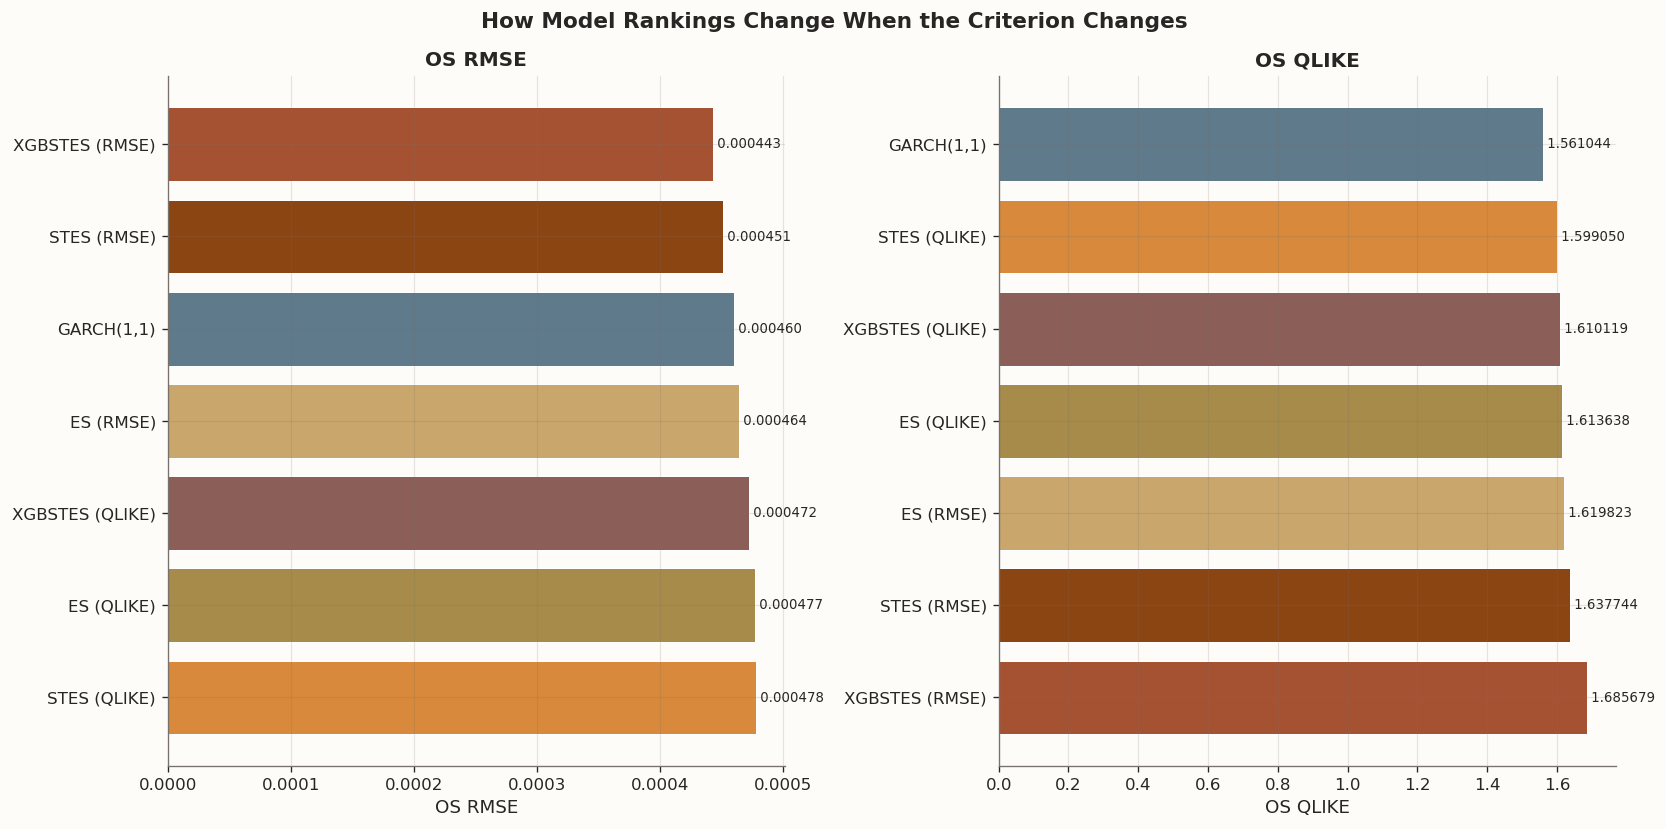

In [96]:
#| label: rmse-qlike-ranking-chart
#| code-summary: "Two-panel ranking chart: OS RMSE and OS QLIKE"

plot_df = comparison_table.copy()
plot_df["Palette"] = plot_df["Model"].map(
    {
        "GARCH(1,1)": "#5F7A8A",
        "ES (RMSE)": "#C9A66B",
        "ES (QLIKE)": "#A68B4B",
        "STES (RMSE)": BLOG_PALETTE[0],
        "XGBSTES (RMSE)": BLOG_PALETTE[1],
        "STES (QLIKE)": "#D8893B",
        "XGBSTES (QLIKE)": "#8C5E58",
    }
)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
for ax, metric in zip(axes, ["OS RMSE", "OS QLIKE"]):
    chart_df = plot_df.sort_values(metric, ascending=True).reset_index(drop=True)
    bars = ax.barh(
        chart_df["Model"],
        chart_df[metric],
        color=chart_df["Palette"],
        edgecolor="white",
        linewidth=0.6,
    )
    ax.set_title(metric, fontsize=12, fontweight="bold")
    ax.set_xlabel(metric)
    ax.invert_yaxis()
    for bar, val in zip(bars, chart_df[metric]):
        ax.text(val, bar.get_y() + bar.get_height() / 2, f" {val:.6f}", va="center", fontsize=8)

fig.suptitle("How Model Rankings Change When the Criterion Changes", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

## Conclusion

Running seven model variants through a symmetric training experiment — each family fitted under both RMSE and QLIKE wherever feasible — produces two clear take-aways:

1. **The training loss reshuffles rankings, but only within the metric it targets.**
   Under RMSE, the top three models are all RMSE-trained; under QLIKE, the top three are all QLIKE-aligned (GARCH MLE, STES QLIKE, XGBSTES QLIKE).  No single model dominates both lists, confirming that the loss function is a design choice that trades accuracy on one criterion for accuracy on the other.

2. **GARCH's MLE is already QLIKE, and it shows.**
   GARCH(1,1) is the only model that lands in the top three under *both* criteria (3rd in RMSE, 1st in QLIKE).  There is no separate "QLIKE-trained GARCH" because MLE already minimizes QLIKE for a Gaussian likelihood; this structural advantage makes GARCH a strong default when the practitioner's criterion is uncertain.

The experiment also reveals what it leaves unanswered.  All models here use the same three gate features (constant, return, realized variance) and a single in-sample/out-of-sample split.  Whether richer feature sets or more sophisticated time-series cross-validation would change the rankings is the subject of [Part 5](../volatility-forecasts-5/).

### What's next

We will tackle the following things in the next few posts.

1. **Feature expansion** — adding trailing realized-variance windows, calendar and event indicators, and CFTC positioning data to the gate inputs.
2. **Regularization** — deriving and implementing adaptive lasso and elastic net for the STES gate under both RMSE (coordinate descent) and QLIKE (proximal L-BFGS), so we can expand the feature set without overfitting.
3. **Train/test split** — comparing model performance using more sophisticated time-series splits to create real-time variance forecasts and DM statistics.


## Appendix: GARCH(1,1) Model Recap and MLE

We quickly give a self-contained recap of the GARCH(1,1) model and derive its maximum-likelihood estimator step by step. The aim is to show that GARCH MLE is mathematically equivalent to QLIKE, a statement we made above.

### The model

GARCH(1,1) ([Bollerslev, 1986](https://doi.org/10.1016/0304-4076(86)90063-1)) specifies a conditionally Gaussian return process:

$$
r_t = \sigma_t \, \epsilon_t, \qquad \epsilon_t \overset{\text{iid}}{\sim} N(0,\,1),
$$

where the conditional variance $\sigma_t^2 \equiv \text{Var}(r_t \mid \mathcal{F}_{t-1})$ follows the recursion

$$
\sigma_t^2 = \omega + \alpha \, r_{t-1}^2 + \beta \, \sigma_{t-1}^2.
$$

The three parameters $(\omega, \alpha, \beta)$ are constrained to $\omega > 0$, $\alpha \ge 0$, $\beta \ge 0$ to keep the variance positive, and $\alpha + \beta < 1$ for covariance stationarity. The unconditional variance is $\bar\sigma^2 = \omega / (1 - \alpha - \beta)$.

Intuitively, the recursion says: today's variance is a weighted combination of a long-run baseline ($\omega$), yesterday's squared return ($\alpha r_{t-1}^2$, the "shock" component), and yesterday's conditional variance ($\beta \sigma_{t-1}^2$, the "persistence" component). When $\beta$ is large — typically 0.85–0.95 for daily equity returns — variance shocks decay slowly, which captures the well-known volatility clustering in financial returns.

### Maximum likelihood estimation

GARCH parameters are fit by maximum likelihood. Given a sample of returns $(r_1, \ldots, r_T)$ and an initial variance $\sigma_1^2$ (usually set to the sample variance), each observation has the conditional density

$$
p(r_t \mid \mathcal{F}_{t-1}) = \frac{1}{\sqrt{2\pi\,\sigma_t^2}} \exp\!\left(-\frac{r_t^2}{2\,\sigma_t^2}\right).
$$

Taking logs:

$$
\log p(r_t \mid \mathcal{F}_{t-1}) = -\tfrac{1}{2}\log(2\pi) - \tfrac{1}{2}\log \sigma_t^2 - \frac{r_t^2}{2\,\sigma_t^2}.
$$

The full-sample log-likelihood is the sum over all observations:

$$
\ell(\omega, \alpha, \beta) = \sum_{t=1}^{T} \log p(r_t \mid \mathcal{F}_{t-1})
= -\frac{T}{2}\log(2\pi) - \frac{1}{2}\sum_{t=1}^{T}\left[\log \sigma_t^2 + \frac{r_t^2}{\sigma_t^2}\right].
$$

Since $-\frac{T}{2}\log(2\pi)$ is a constant that does not depend on the parameters, maximizing $\ell$ is equivalent to minimizing

$$
\mathcal{L}_{\text{MLE}} = \sum_{t=1}^{T}\left[\log \sigma_t^2 + \frac{r_t^2}{\sigma_t^2}\right].
$$

### MLE is QLIKE

Now identify the GARCH forecast with the generic variance forecast: $\hat v_t = \sigma_t^2$, and the squared return with the realized-variance proxy: $y_t = r_t^2$. The MLE objective becomes

$$
\mathcal{L}_{\text{MLE}} = \sum_{t=1}^{T}\left[\log \hat v_t + \frac{y_t}{\hat v_t}\right].
$$

Compare this with the QLIKE loss defined in the Methodology section:

$$
\mathcal{L}_{\text{QLIKE}} = \sum_{t=1}^{T}\left[\frac{y_t}{\hat v_t} - \log\!\left(\frac{y_t}{\hat v_t}\right) - 1\right]
= \sum_{t=1}^{T}\left[\frac{y_t}{\hat v_t} + \log \hat v_t \underbrace{{} - \log y_t - 1}_{\text{constant in } \hat v}\right].
$$

The two expressions differ only by $-\log y_t - 1$, which is constant with respect to $(\omega, \alpha, \beta)$. Maximizing the Gaussian log-likelihood and minimizing QLIKE produce exactly the same parameter estimates.

This equivalence is by design — QLIKE is the evaluation counterpart of the Gaussian quasi-likelihood. The result holds even when returns are non-Gaussian, because the Gaussian log-likelihood is a proper *quasi-likelihood* for the conditional variance: its first-order conditions are unbiased under any distribution with the correct conditional mean and variance ([Bollerslev and Wooldridge, 1992](https://doi.org/10.2307/2297877)). That robustness is what makes MLE the default fitting procedure for GARCH in practice, and what makes QLIKE the natural evaluation metric for variance forecasts.

### Why not fit GARCH under MSE?

One could in principle fit GARCH under MSE instead — minimizing $\sum_t (r_t^2 - \sigma_t^2)^2$ over the recursion parameters. This is sometimes called LS-GARCH (least-squares GARCH), though it is non-standard for good reason. MSE treats all observations equally in absolute terms, so a few large volatility spikes dominate the loss surface and can distort parameter estimates. MLE under the Gaussian quasi-likelihood is more statistically efficient: it weights each observation proportionally to its variance, which is the natural scale for a variance model. The `arch` package — and nearly all GARCH implementations in practice — fits by MLE only.
